In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

df = pd.read_csv("database.csv")
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce', utc=True)
if df['Timestamp'].isna().any():
    mask = df['Timestamp'].isna()
    df.loc[mask, 'Timestamp'] = pd.to_datetime(df.loc[mask, 'Date'], errors='coerce', utc=True)
df = df.dropna(subset=['Timestamp']).reset_index(drop=True)
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

In [2]:
def mag_to_energy(m):
  return 10**((m + 10.7)*1.5)
def energy_to_mag(e):
  return (2/3)*np.log10(e) - 10.7
#will sum the total energy released by all earthquakes in a cell, then convert this total energy back to moment magnitude

In [3]:
lat_bins = np.arange(-90, 91, 1)
lon_bins = np.arange(-180,181,1)

all_months = pd.date_range(start=df['Timestamp'].min().replace(day=1),
                           end=df['Timestamp'].max(),
                           freq='MS')

df['lat_index'] = np.digitize(df['Latitude'], lat_bins) - 1
df['lon_index'] = np.digitize(df['Longitude'], lon_bins) - 1
df['time_index'] = df['Timestamp'].dt.to_period('M')
df['Moment'] = df['Magnitude'].apply(mag_to_energy)

grid_data = df.groupby(['time_index', 'lat_index', 'lon_index'])['Moment'].sum().reset_index()
n_time = len(all_months)
n_lat = len(lat_bins) - 1
n_lon = len(lon_bins) - 1
tensor = np.zeros((n_time, 1, n_lat, n_lon)) # initialize 4D tensor (time, channels, lat, lon)

#fill in the tensor
month_to_index = {p: i for i, p in enumerate(all_months.to_period('M'))}
for _, row in grid_data.iterrows():
  t = month_to_index[row['time_index']]
  tensor[t, 0, int(row['lat_index']), int(row['lon_index'])] = energy_to_mag(row['Moment'])
print(f"Tensor Shape: {tensor.shape}")

/tmp/ipykernel_6037/3596356635.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['time_index'] = df['Timestamp'].dt.to_period('M')
/tmp/ipykernel_6037/3596356635.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month_to_index = {p: i for i, p in enumerate(all_months.to_period('M'))}


Tensor Shape: (624, 1, 180, 360)


In [4]:
class EarthquakeDataset(Dataset):
  def __init__(self, tensor, window_size=12):
    # tensor: np.array of shape (time, channels, lat, lon)
    #window_size: number of past months to use for prediction
    self.data = torch.FloatTensor(tensor) / 10.0 # keeping magnitudes in the range 0-1 to help model learn faster
    self.window_size = window_size

  def __len__(self):
    return len(self.data) - self.window_size

  def __getitem__(self, index):
    x = self.data[index : index + self.window_size] # get the input
    y = self.data[index + self.window_size] # get the target month immediately following the window
    return x, y

window_size = 12
full_ds = EarthquakeDataset(tensor, window_size=window_size)
split_index = int(0.8 * len(full_ds)) #training data will come from earlier time period, test data will be latest time period.
train_ds = torch.utils.data.Subset(full_ds, range(0, split_index))
test_ds = torch.utils.data.Subset(full_ds, range(split_index, len(full_ds)))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)


In [5]:
class EarthquakeModel(nn.Module):
  def __init__(self, window_size=12):
    super(EarthquakeModel, self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(1,16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.lstm_input_size = 32 * 45 * 90
    self.lstm = nn.LSTM(input_size=self.lstm_input_size, hidden_size=512, num_layers=2, batch_first=True)
    self.fc = nn.Linear(512, self.lstm_input_size)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(32,16, kernel_size=2, stride=2),
        nn.ReLU(),
        nn.ConvTranspose2d(16,1, kernel_size=2, stride=2),
        nn.Sigmoid()
    )

  def forward(self, x):
    batch_size, seq_len, c, h, w = x.size()
    x = x.view(batch_size * seq_len, c, h, w)
    x = self.encoder(x)

    x = x.view(batch_size, seq_len, -1)
    x, _ = self.lstm(x)

    x = x[:, -1, :]
    x = self.fc(x)
    x = x.view(batch_size, 32, 45, 90)
    x = self.decoder(x)
    return x

model = EarthquakeModel().to('cuda')

In [6]:
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

learning_rate = 1e-4
epochs = 50
pos_weight = 50.0

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss(reduction='none')
scaler = GradScaler()

def train_one_epoch(loader, model, optimizer, device):
  model.train()
  total_loss = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    with autocast():
      preds = model(x)
      loss_map = criterion(preds, y)
      weight_mask = torch.ones_like(y)
      weight_mask[y > 0] = pos_weight
      weighted_loss = (loss_map * weight_mask).mean()
    scaler.scale(weighted_loss).backward()
    scaler.step(optimizer)
    scaler.update()

    total_loss += weighted_loss.item()
  return total_loss/len(loader)

device = "cuda" if torch.cuda.is_available() else "cpu"
for epoch in range(epochs):
  train_loss = train_one_epoch(train_loader, model, optimizer, device)
  print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.6f}")

/tmp/ipykernel_6037/2738714680.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_6037/2738714680.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/50 | Loss: 0.198488
Epoch 2/50 | Loss: 0.055849
Epoch 3/50 | Loss: 0.015172
Epoch 4/50 | Loss: 0.007865
Epoch 5/50 | Loss: 0.006078
Epoch 6/50 | Loss: 0.005498
Epoch 7/50 | Loss: 0.005191
Epoch 8/50 | Loss: 0.005048
Epoch 9/50 | Loss: 0.004930
Epoch 10/50 | Loss: 0.004818
Epoch 11/50 | Loss: 0.004770
Epoch 12/50 | Loss: 0.004711
Epoch 13/50 | Loss: 0.004690
Epoch 14/50 | Loss: 0.004662
Epoch 15/50 | Loss: 0.004624
Epoch 16/50 | Loss: 0.004596
Epoch 17/50 | Loss: 0.004594
Epoch 18/50 | Loss: 0.004579
Epoch 19/50 | Loss: 0.004573
Epoch 20/50 | Loss: 0.004560
Epoch 21/50 | Loss: 0.004577
Epoch 22/50 | Loss: 0.004527
Epoch 23/50 | Loss: 0.004549
Epoch 24/50 | Loss: 0.004532
Epoch 25/50 | Loss: 0.004520
Epoch 26/50 | Loss: 0.004497
Epoch 27/50 | Loss: 0.004515
Epoch 28/50 | Loss: 0.004526
Epoch 29/50 | Loss: 0.004504
Epoch 30/50 | Loss: 0.004539
Epoch 31/50 | Loss: 0.004504
Epoch 32/50 | Loss: 0.004487
Epoch 33/50 | Loss: 0.004493
Epoch 34/50 | Loss: 0.004469
Epoch 35/50 | Loss: 0.0

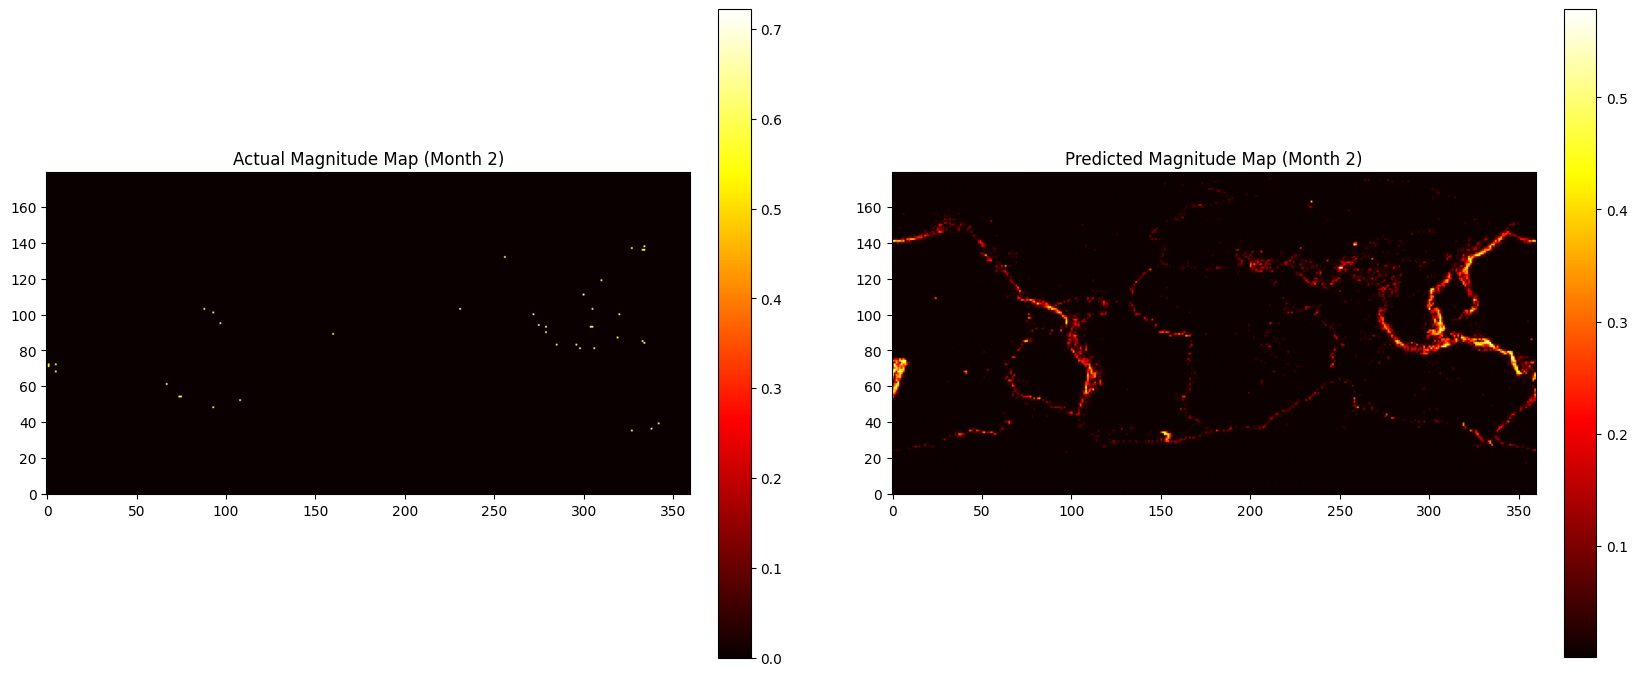

In [7]:
def plot_prediction(model, dataset, index=0):
  model.eval()
  with torch.no_grad():
    x, y = dataset[index]
    x = x.unsqueeze(0).to('cuda')
    pred = model(x).squeeze().cpu().numpy()
    actual = y.squeeze().cpu().numpy()
  fig, axes = plt.subplots(1, 2, figsize = (20,10))

  im1 = axes[0].imshow(actual, cmap='hot', origin='lower')
  axes[0].set_title(f"Actual Magnitude Map (Month {index})")
  plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

  im2 = axes[1].imshow(pred, cmap='hot', origin='lower')
  axes[1].set_title(f"Predicted Magnitude Map (Month {index})")
  plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

  plt.show()

plot_prediction(model, test_ds, index=2)

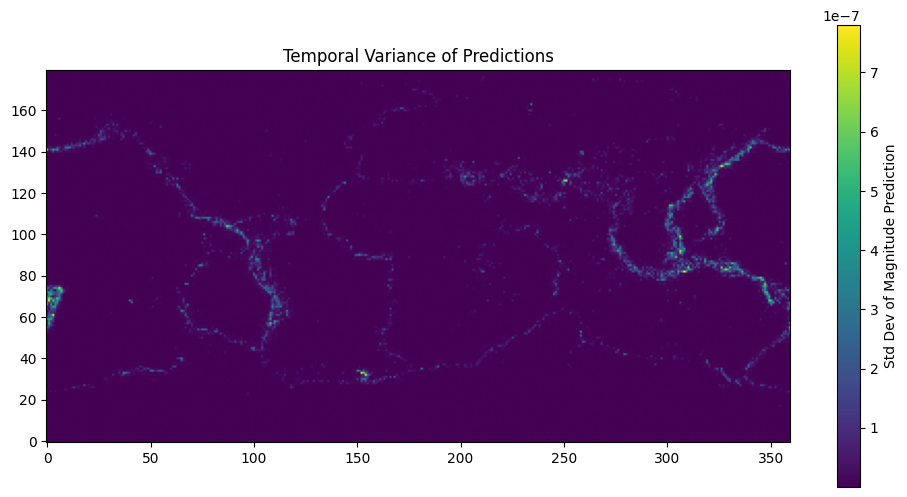

In [8]:
#check if the model is actually adjusting its predictions across different months
def check_temporal_variance(model, loader):
  model.eval()
  all_preds = []
  with torch.no_grad():
    for x, _ in loader:
      pred = model(x.to('cuda')).cpu().numpy()
      all_preds.append(pred)
  full_pred_history = np.concatenate(all_preds, axis=0).squeeze()
  temporal_std = np.std(full_pred_history, axis=0)
  plt.figure(figsize=(12, 6))
  plt.imshow(temporal_std, cmap='viridis', origin='lower')
  plt.title("Temporal Variance of Predictions")
  plt.colorbar(label="Std Dev of Magnitude Prediction")
  plt.show()

check_temporal_variance(model, test_loader)


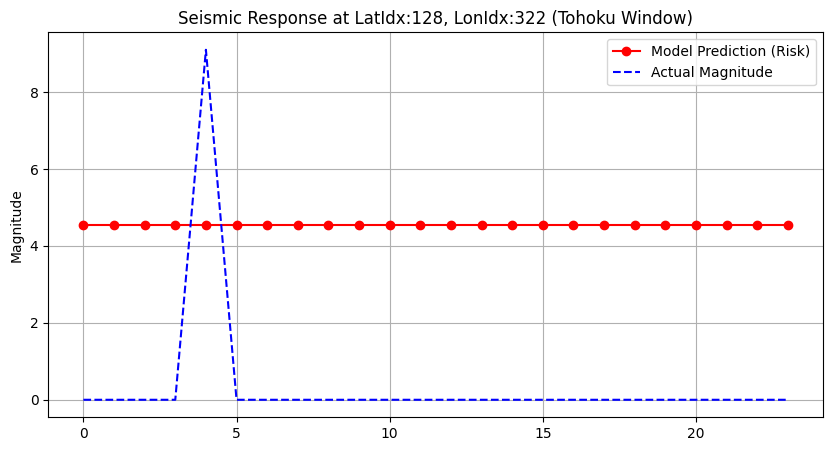

In [9]:
def plot_pixel_timeline(model, full_tensor, lat_idx, lon_idx, start_month_index, duration=24):
    #plots the model's prediction for specific coordinates over a window a time

    model.eval()
    predictions = []
    actuals = []

    for i in range(start_month_index, start_month_index + duration):
        x = torch.FloatTensor(full_tensor[i-12:i]).unsqueeze(0).to('cuda') / 10.0
        target = full_tensor[i, 0, lat_idx, lon_idx]

        with torch.no_grad():
            pred = model(x).squeeze().cpu().numpy()[lat_idx, lon_idx] * 10.0

        predictions.append(pred)
        actuals.append(target)

    plt.figure(figsize=(10, 5))
    plt.plot(predictions, label="Model Prediction (Risk)", color='red', marker='o')
    plt.plot(actuals, label="Actual Magnitude", color='blue', linestyle='--')
    plt.title(f"Seismic Response at LatIdx:{lat_idx}, LonIdx:{lon_idx} (Tohoku Window)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid(True)
    plt.show()


#Japan Index for 1-degree grid: lat 38N -> index 128, lon 142E -> index 322
plot_pixel_timeline(model, tensor, lat_idx=128, lon_idx=322, start_month_index=550)

This model is merely outputting a static heatmap of earthquake likelihood which does not change month by month, indicating that the model has failed to take into account temporal relationships of earthquakes.

In [10]:
class EarthquakeBinaryDataset(Dataset):
  def __init__(self, tensor, window_size=12, threshold=0.15):
    #trying a model with binary event prediction, and adding a new channel for the delta of the magnitude from the previous month
    self.data = torch.FloatTensor(tensor) / 10.0
    self.window_size = window_size
    self.threshold = threshold

  def __len__(self):
    return len(self.data) - self.window_size - 1

  def __getitem__(self, index):
    index = index + 1
    raw_seq = self.data[index : index + self.window_size]
    prev_seq = self.data[index-1 : index + self.window_size - 1]
    delta_seq = raw_seq - prev_seq

    x = torch.cat([raw_seq, delta_seq], dim=1)
    target_grid = self.data[index + self.window_size]
    y = (target_grid > self.threshold).float()
    return x, y

window_size = 6
full_ds = EarthquakeBinaryDataset(tensor, window_size=window_size)
split_index = int(0.8 * len(full_ds))
train_ds = torch.utils.data.Subset(full_ds, range(0, split_index))
test_ds = torch.utils.data.Subset(full_ds, range(split_index, len(full_ds)))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

In [11]:
class EarthquakeBinaryModel(nn.Module):
  def __init__(self, window_size=12):
    super(EarthquakeBinaryModel, self).__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(2,16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(16,32,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.lstm = nn.LSTM(input_size=32*45*90, hidden_size=512, num_layers=2, batch_first=True)
    self.fc = nn.Linear(512, 32*45*90)
    self.decoder = nn.Sequential(
        nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
        nn.ReLU(),
        nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2)
        # no sigmoid here, because using BCEWithLogitsLoss
    )

  def forward(self, x):
    batch_size, seq_len, c, h, w = x.size()
    x = x.view(batch_size * seq_len, c, h, w)
    x = self.encoder(x)

    x = x.view(batch_size, seq_len, -1)
    x, _ = self.lstm(x)

    x = x[:, -1, :]
    x = self.fc(x)
    x = x.view(batch_size, 32, 45, 90)
    x = self.decoder(x)
    return x

model = EarthquakeBinaryModel().to('cuda')

In [12]:
learning_rate = 1e-4
epochs = 50
pos_weight = 200.0

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to('cuda'))
scaler = GradScaler()

def train_binary_epoch(loader, model, optimizer, device):
  model.train()
  total_loss = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss/len(loader)

device = "cuda" if torch.cuda.is_available() else "cpu"
for epoch in range(epochs):
  train_loss = train_binary_epoch(train_loader, model, optimizer, device)
  print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.6f}")

/tmp/ipykernel_6037/732367589.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/50 | Loss: 0.490236
Epoch 2/50 | Loss: 0.217854
Epoch 3/50 | Loss: 0.135090
Epoch 4/50 | Loss: 0.113705
Epoch 5/50 | Loss: 0.104836
Epoch 6/50 | Loss: 0.099662
Epoch 7/50 | Loss: 0.096091
Epoch 8/50 | Loss: 0.093585
Epoch 9/50 | Loss: 0.091615
Epoch 10/50 | Loss: 0.090037
Epoch 11/50 | Loss: 0.088572
Epoch 12/50 | Loss: 0.087493
Epoch 13/50 | Loss: 0.086676
Epoch 14/50 | Loss: 0.086017
Epoch 15/50 | Loss: 0.085352
Epoch 16/50 | Loss: 0.084937
Epoch 17/50 | Loss: 0.084497
Epoch 18/50 | Loss: 0.084252
Epoch 19/50 | Loss: 0.083840
Epoch 20/50 | Loss: 0.083402
Epoch 21/50 | Loss: 0.083218
Epoch 22/50 | Loss: 0.082978
Epoch 23/50 | Loss: 0.082706
Epoch 24/50 | Loss: 0.082637
Epoch 25/50 | Loss: 0.082379
Epoch 26/50 | Loss: 0.082280
Epoch 27/50 | Loss: 0.082089
Epoch 28/50 | Loss: 0.081997
Epoch 29/50 | Loss: 0.081881
Epoch 30/50 | Loss: 0.081764
Epoch 31/50 | Loss: 0.081601
Epoch 32/50 | Loss: 0.081488
Epoch 33/50 | Loss: 0.081366
Epoch 34/50 | Loss: 0.081254
Epoch 35/50 | Loss: 0.0

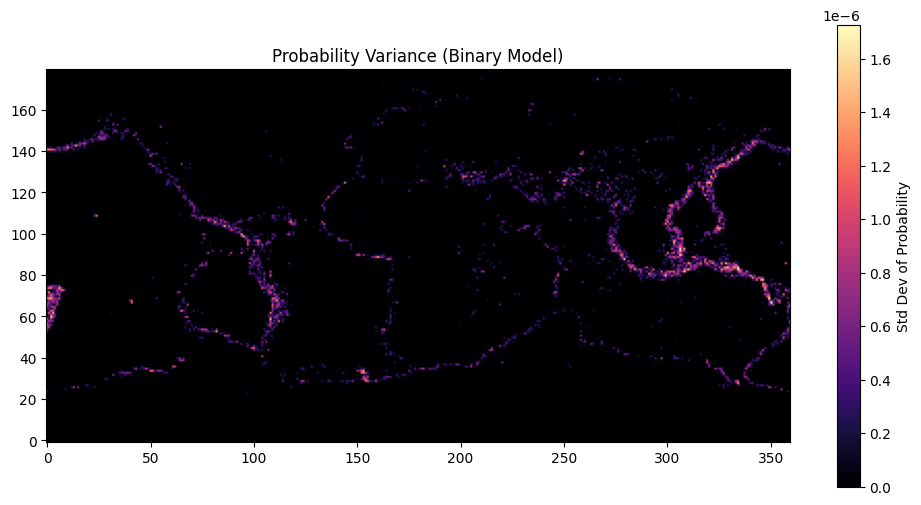

In [13]:
def check_binary_temporal_variance(model, loader):
  model.eval()
  all_probs = []
  with torch.no_grad():
    for x, _ in loader:
      logits = model(x.to('cuda'))
      probs = torch.sigmoid(logits).cpu().numpy()
      all_probs.append(probs)

  full_prob_history = np.concatenate(all_probs, axis=0).squeeze()
  temporal_std = np.std(full_prob_history, axis=0)
  plt.figure(figsize=(12, 6))
  plt.imshow(temporal_std, cmap='magma', origin='lower')
  plt.title("Probability Variance (Binary Model)")
  plt.colorbar(label="Std Dev of Probability")
  plt.show()
check_binary_temporal_variance(model, test_loader)


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_binary_performance(model, loader, prob_threshold=0.5):
  model.eval()
  y_true = []
  y_pred = []
  with torch.no_grad():
    for x, y in loader:
      logits = model(x.to('cuda'))
      probs = torch.sigmoid(logits).cpu().numpy().flatten()
      targets = y.cpu().numpy().flatten()
      y_true.extend(targets)
      y_pred.extend((probs > prob_threshold).astype(int))

  print(f"--- Classification Report (Threshold {prob_threshold}) ---")
  print(classification_report(y_true, y_pred, target_names=["No Event", "M6.3+ Event"]))

  cm = confusion_matrix(y_true, y_pred)
  print("Confusion Matrix:")
  print(cm)

evaluate_binary_performance(model, test_loader, prob_threshold=0.5)


--- Classification Report (Threshold 0.5) ---
              precision    recall  f1-score   support

    No Event       1.00      0.98      0.99   8031037
 M6.3+ Event       0.02      0.73      0.03      4163

    accuracy                           0.98   8035200
   macro avg       0.51      0.85      0.51   8035200
weighted avg       1.00      0.98      0.99   8035200

Confusion Matrix:
[[7860219  170818]
 [   1133    3030]]


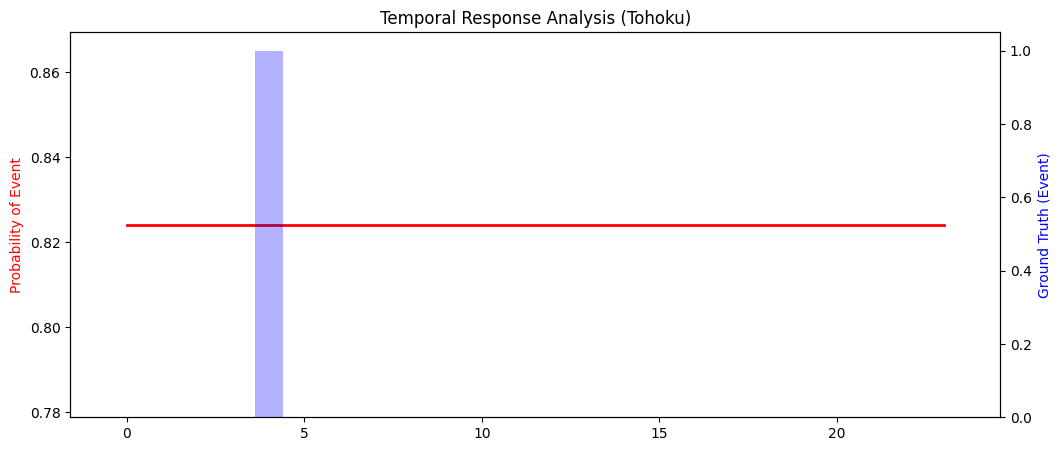

In [15]:
def plot_binary_pixel_timeline(model, full_tensor, lat_index, lon_index, start_month_index, duration=24, location = "Tohoku"):
  model.eval()
  prob_history = []
  actual_events = []
  for i in range(start_month_index, start_month_index + duration):
    raw_seq = torch.FloatTensor(full_tensor[i-6:i])/10.0
    prev_seq = torch.FloatTensor(full_tensor[i-7:i-1])/10.0
    delta_seq = raw_seq - prev_seq
    x = torch.cat([raw_seq, delta_seq], dim=1).unsqueeze(0).to('cuda')
    with torch.no_grad():
      logits = model(x)
      prob = torch.sigmoid(logits).squeeze().cpu().numpy()[lat_index, lon_index]
    prob_history.append(prob)
    actual_events.append(1 if full_tensor[i, 0, lat_index, lon_index] > 0.15 else 0)
  plt.figure(figsize=(12,5))
  ax1 = plt.gca()
  ax2 = ax1.twinx()

  ax1.plot(prob_history, color='red', label="Model Probability", linewidth=2)
  ax2.bar(range(duration), actual_events, alpha=0.3, color='blue', label='Actual M6.3+ event')
  ax1.set_ylabel('Probability of Event', color='red')
  ax2.set_ylabel('Ground Truth (Event)', color='blue')
  plt.title(f"Temporal Response Analysis ({location})")
  plt.show()

plot_binary_pixel_timeline(model, tensor, lat_index=128, lon_index=322, start_month_index=550)

In [16]:
#ConvLSTM implementation based on https://github.com/ndrplz/ConvLSTM_pytorch

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size // 2
        self.bias = bias

        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim,
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)

        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

In [17]:
class EarthquakeConvLSTM(nn.Module):
    def __init__(self):
        super(EarthquakeConvLSTM, self).__init__()
        self.cell1 = ConvLSTMCell(input_dim=2, hidden_dim=16, kernel_size=3, bias=True)
        self.cell2 = ConvLSTMCell(input_dim=16, hidden_dim=8, kernel_size=3, bias=True)
        self.final_conv = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, x):
        b, seq_len, _, h, w = x.size()

        h1, c1 = torch.zeros(b, 16, h, w).to(x.device), torch.zeros(b, 16, h, w).to(x.device)
        h2, c2 = torch.zeros(b, 8, h, w).to(x.device), torch.zeros(b, 8, h, w).to(x.device)

        for t in range(seq_len):
            h1, c1 = self.cell1(x[:, t, :, :, :], (h1, c1))
            h2, c2 = self.cell2(h1, (h2, c2))

        return self.final_conv(h2)

model = EarthquakeConvLSTM().to('cuda')

In [18]:
learning_rate = 1e-4
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
epochs = 150
pos_weight = 200.0

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to('cuda'))
scaler = GradScaler()

def train_binary_epoch(loader, model, optimizer, device):
  model.train()
  total_loss = 0
  for x, y in loader:
    x, y = x.to(device), y.to(device)
    optimizer.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
  return total_loss/len(loader)

device = "cuda" if torch.cuda.is_available() else "cpu"
for epoch in range(epochs):
  train_loss = train_binary_epoch(train_loader, model, optimizer, device)
  scheduler.step(train_loss)
  print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss:.6f}")

/tmp/ipykernel_6037/851851756.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/150 | Loss: 0.664873
Epoch 2/150 | Loss: 0.567411
Epoch 3/150 | Loss: 0.366740
Epoch 4/150 | Loss: 0.345821
Epoch 5/150 | Loss: 0.340051
Epoch 6/150 | Loss: 0.335900
Epoch 7/150 | Loss: 0.332979
Epoch 8/150 | Loss: 0.330113
Epoch 9/150 | Loss: 0.327780
Epoch 10/150 | Loss: 0.325752
Epoch 11/150 | Loss: 0.324132
Epoch 12/150 | Loss: 0.322617
Epoch 13/150 | Loss: 0.320913
Epoch 14/150 | Loss: 0.319382
Epoch 15/150 | Loss: 0.316603
Epoch 16/150 | Loss: 0.312199
Epoch 17/150 | Loss: 0.305397
Epoch 18/150 | Loss: 0.297926
Epoch 19/150 | Loss: 0.289508
Epoch 20/150 | Loss: 0.280941
Epoch 21/150 | Loss: 0.272766
Epoch 22/150 | Loss: 0.265729
Epoch 23/150 | Loss: 0.259746
Epoch 24/150 | Loss: 0.253907
Epoch 25/150 | Loss: 0.248288
Epoch 26/150 | Loss: 0.242896
Epoch 27/150 | Loss: 0.237074
Epoch 28/150 | Loss: 0.231756
Epoch 29/150 | Loss: 0.227376
Epoch 30/150 | Loss: 0.224638
Epoch 31/150 | Loss: 0.222633
Epoch 32/150 | Loss: 0.220926
Epoch 33/150 | Loss: 0.219271
Epoch 34/150 | Loss

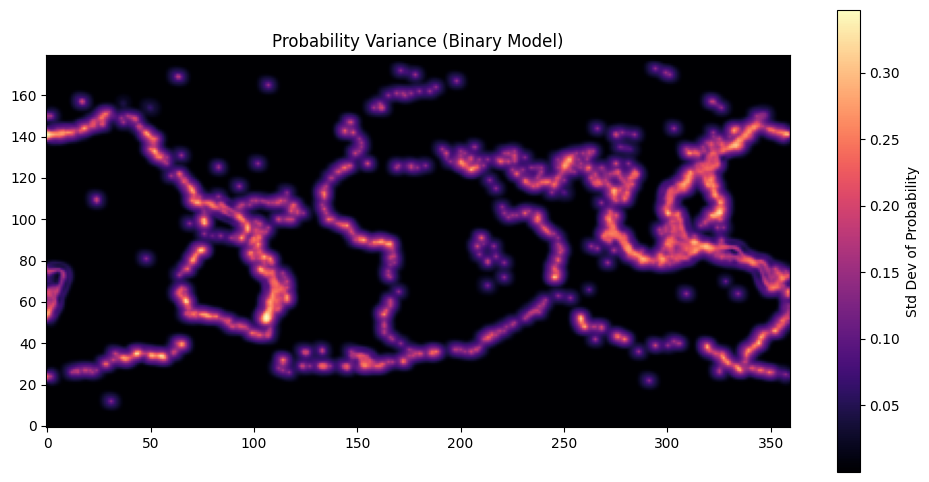

In [19]:
check_binary_temporal_variance(model, test_loader)

In [20]:
evaluate_binary_performance(model, test_loader, prob_threshold=0.5)

--- Classification Report (Threshold 0.5) ---
              precision    recall  f1-score   support

    No Event       1.00      0.98      0.99   8031037
 M6.3+ Event       0.02      0.53      0.03      4163

    accuracy                           0.98   8035200
   macro avg       0.51      0.76      0.51   8035200
weighted avg       1.00      0.98      0.99   8035200

Confusion Matrix:
[[7896738  134299]
 [   1962    2201]]


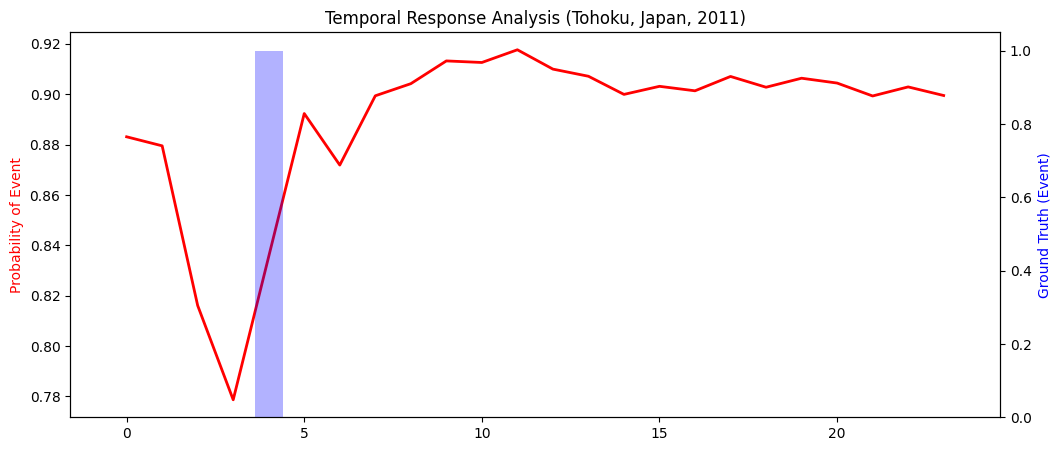

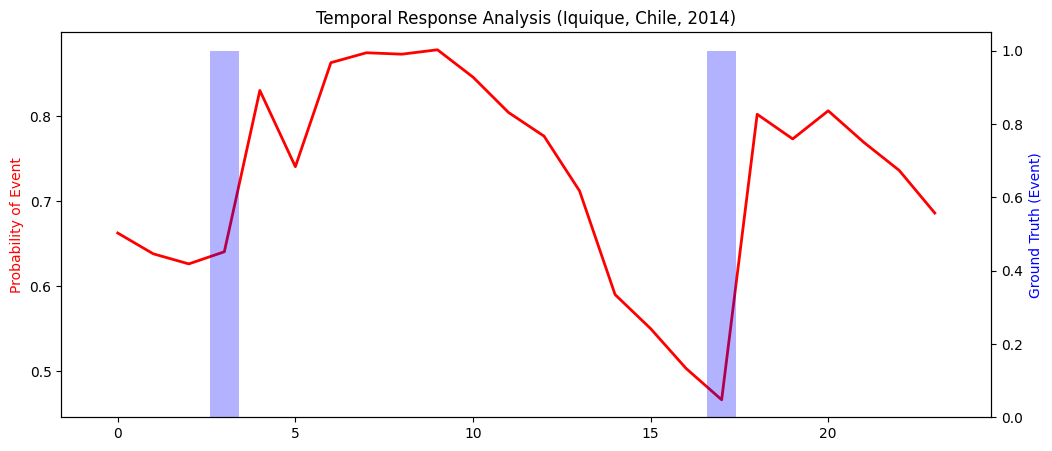

In [21]:
plot_binary_pixel_timeline(model, tensor, lat_index=128, lon_index=322, start_month_index=550, location="Tohoku, Japan, 2011")
plot_binary_pixel_timeline(model, tensor, lat_index=71, lon_index=110, start_month_index=585, location="Iquique, Chile, 2014")

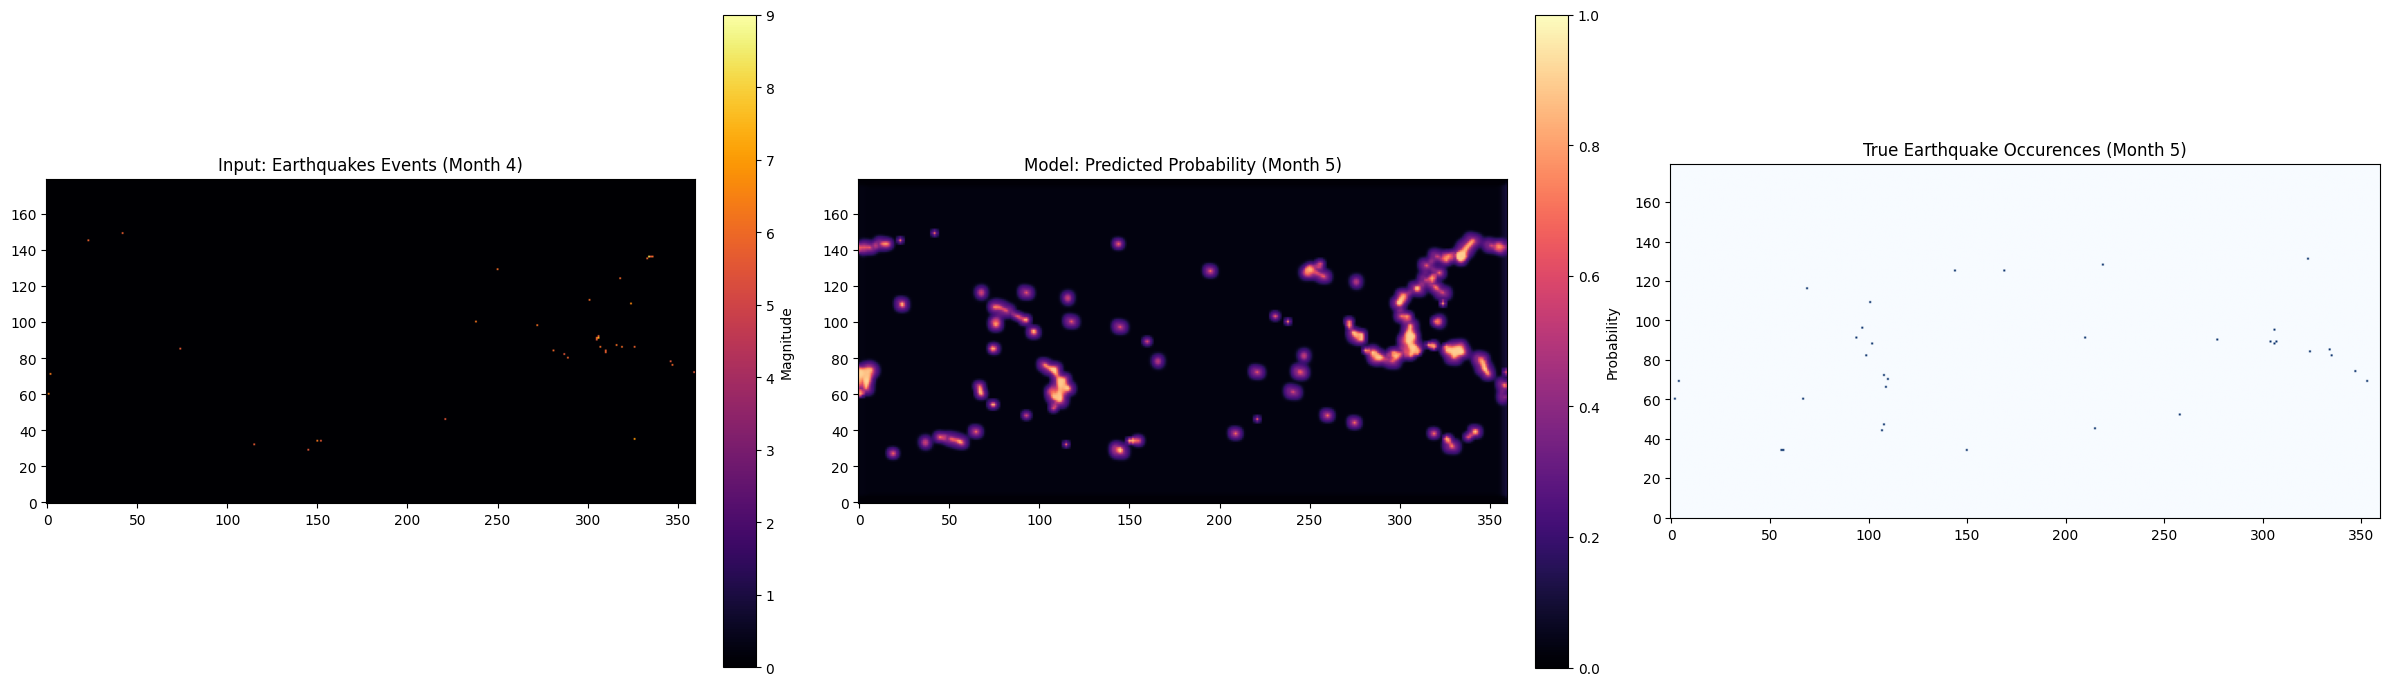

In [22]:
def visualize_monthly_heatmap(model, dataset, month_index):
  model.eval()
  with torch.no_grad():
    x, y = dataset[month_index]
    x_input = x.unsqueeze(0).to('cuda')
    logits = model(x_input)
    prob_map = torch.sigmoid(logits).squeeze().cpu().numpy()
    last_quakes = x[-1, 0, :, :].cpu().numpy() * 10.0
    actual_target = y.squeeze().cpu().numpy()

  fig, axes = plt.subplots(1,3,figsize=(24,8))

  im1 = axes[0].imshow(last_quakes, cmap='inferno', origin='lower', vmin=0,vmax=9)
  axes[0].set_title(f"Input: Earthquakes Events (Month {month_index-1})")
  plt.colorbar(im1, ax=axes[0], label="Magnitude", fraction=0.046, pad=0.04)

  im2 = axes[1].imshow(prob_map, cmap='magma', origin='lower', vmin=0, vmax=1.0)
  axes[1].set_title(f"Model: Predicted Probability (Month {month_index})")
  plt.colorbar(im2, ax=axes[1], label="Probability", fraction=0.046, pad=0.04)

  im3 = axes[2].imshow(actual_target, cmap='Blues', origin='lower')
  axes[2].set_title(f"True Earthquake Occurences (Month {month_index})")
  plt.tight_layout()
  plt.show()

visualize_monthly_heatmap(model, test_ds, month_index=5)

In [23]:
import torch.nn.functional as F
def evaluate_with_tolerance(model, loader, threshold=0.5, radius=1):
  model.eval()
  tp, fp, fn, tn = 0, 0, 0, 0
  with torch.no_grad():
    for x, y in loader:
      logits = model(x.to('cuda'))
      probs = torch.sigmoid(logits)
      preds = (probs > threshold).float()
      targets = y.to('cuda')

      kernel_size = 2*radius + 1
      buffered_targets = F.max_pool2d(targets, kernel_size=kernel_size, stride=1, padding=radius)
      tp += (preds * buffered_targets).sum().item()
      fp += (preds * (1-buffered_targets)).sum().item()
      buffered_preds = F.max_pool2d(preds, kernel_size=kernel_size, stride=1, padding=radius)
      fn += (targets * (1-buffered_preds)).sum().item()
  precision = tp / (tp + fp + 1e-7)
  recall = tp / (tp + fn + 1e-7)
  f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

  print(f"--- Spatial Tolerance Results (Radius: {radius} degree) ---")
  print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

evaluate_with_tolerance(model, test_loader, threshold=0.5, radius=1)
evaluate_with_tolerance(model, test_loader, threshold=0.5, radius=2)


--- Spatial Tolerance Results (Radius: 1 degree) ---
Precision: 0.1130 | Recall: 0.9150 | F1: 0.2012
--- Spatial Tolerance Results (Radius: 2 degree) ---
Precision: 0.2306 | Recall: 0.9662 | F1: 0.3724


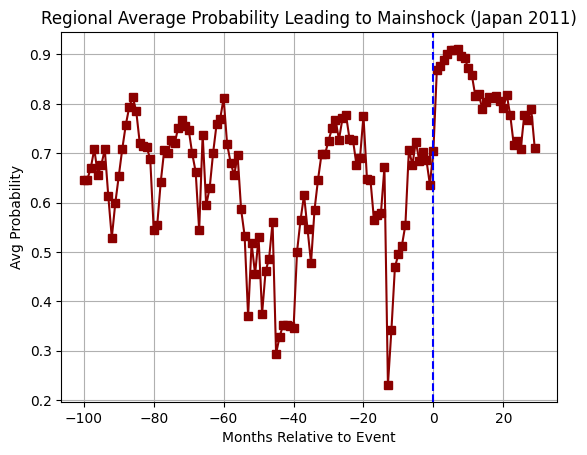

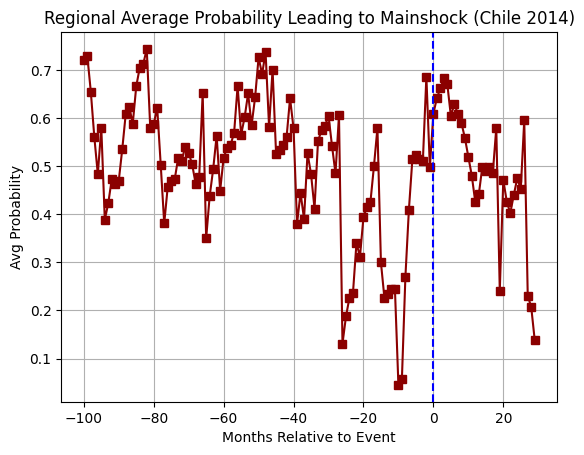

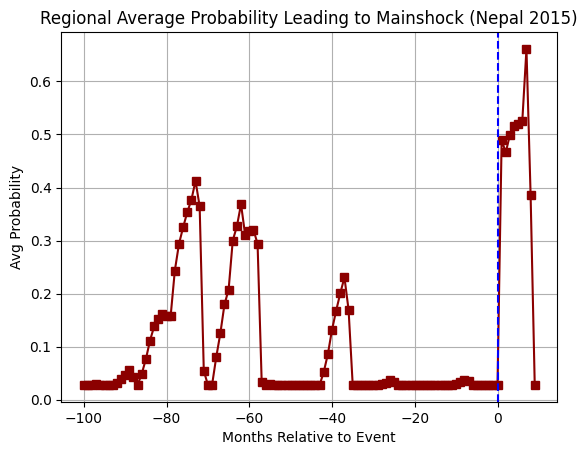

In [24]:
def plot_epicenter_zoom(model, full_tensor, lat_index, lon_index, event_month_index, months_before, months_after, location):
  history = []
  for m in range(event_month_index - months_before, event_month_index + months_after):
    raw_seq = torch.FloatTensor(full_tensor[m-6:m])/10.0
    prev_seq = torch.FloatTensor(full_tensor[m-7:m-1])/10.0
    x=torch.cat([raw_seq, raw_seq - prev_seq], dim=1).unsqueeze(0).to('cuda')
    with torch.no_grad():
      prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
      local_prob = prob[lat_index-2:lat_index+3, lon_index-2:lon_index+3].mean()
      history.append(local_prob)
  plt.plot(range(-1*months_before, months_after), history, marker='s', color='darkred')
  plt.axvline(x=0, color='blue', linestyle='--', label='Mainshock Month')
  plt.title(f"Regional Average Probability Leading to Mainshock ({location})")
  plt.xlabel("Months Relative to Event")
  plt.ylabel("Avg Probability")
  plt.grid(True)
  plt.show()

plot_epicenter_zoom(model,tensor,lat_index=128,lon_index=322,event_month_index=554,months_before=100,months_after=30, location='Japan 2011')
plot_epicenter_zoom(model,tensor,lat_index=71,lon_index=110,event_month_index=591,months_before=100,months_after=30, location = 'Chile 2014')
plot_epicenter_zoom(model,tensor,lat_index=118,lon_index=264,event_month_index=603,months_before=100,months_after=10, location = 'Nepal 2015')